开始流式处理，总数据点：500...


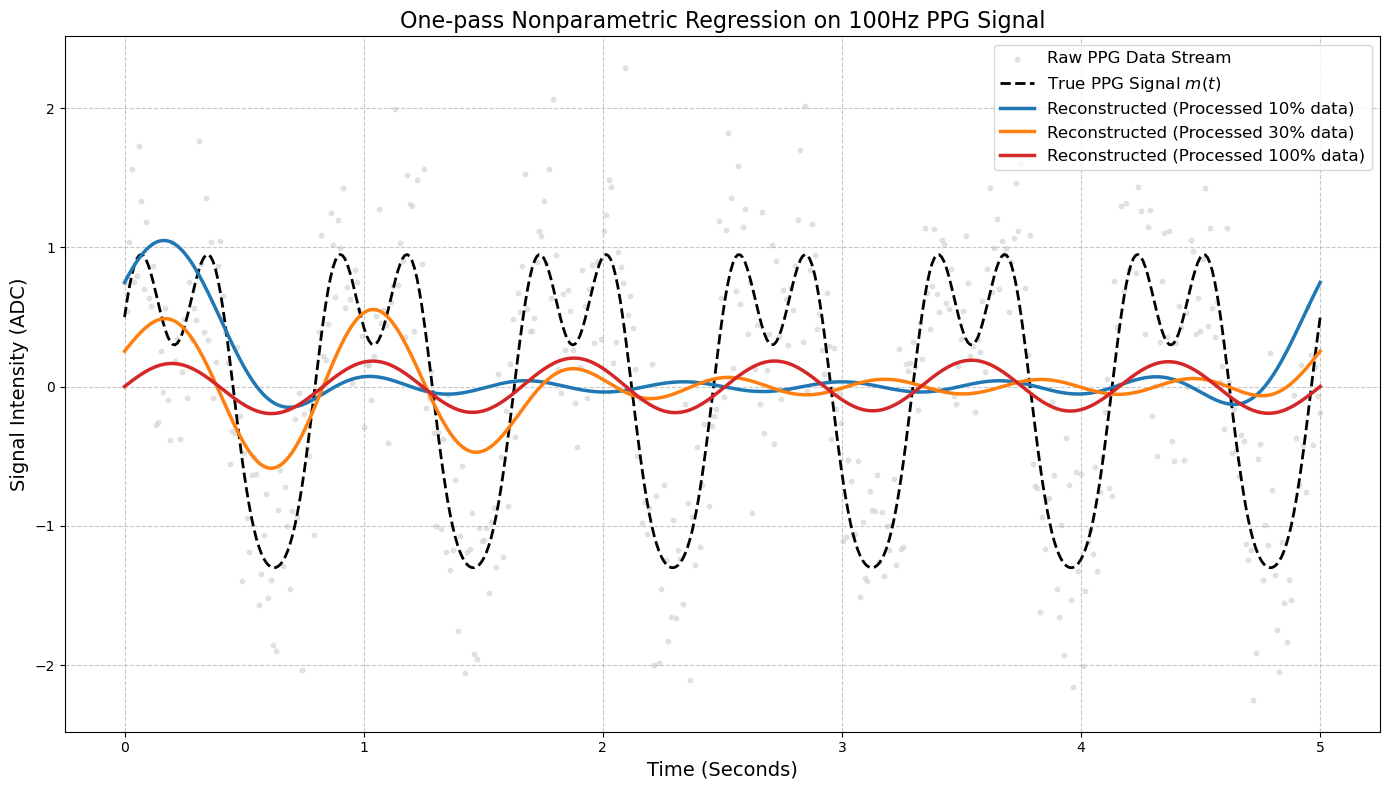

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. 模拟生成 100Hz PPG 原始数据流
# ==========================================
fs = 100         # 采样率 100Hz
L = 5.0          # 观察窗口 5秒
n_samples = int(fs * L)
t = np.linspace(0, L, n_samples)

# 真实的PPG波形：包含心率基频与反映生理特征的谐波
hr_freq = 1.2    # 模拟心率 72 bpm
true_ppg = (np.sin(2 * np.pi * hr_freq * t) + 
            0.5 * np.cos(2 * np.pi * 2 * hr_freq * t) + 
            0.2 * np.sin(2 * np.pi * 3 * hr_freq * t))

# 模拟传感器读取的原始数据 (加入高斯白噪声)
np.random.seed(42)
noise = np.random.normal(0, 0.5, n_samples)
y_raw = true_ppg + noise

# ==========================================
# 2. 定义傅里叶基函数及其粗糙度惩罚矩阵 W
# ==========================================
q = 15  # 使用的基函数总数 (1个常数项 + 7对正余弦)

def get_phi(t_val, L, q):
    """计算给定时间 t_val 下的 q 维傅里叶正交基向量"""
    phi = np.zeros(q)
    phi[0] = 1 / np.sqrt(L)
    for k in range(1, (q + 1) // 2):
        phi[2*k - 1] = np.sqrt(2/L) * np.cos(2 * np.pi * k * t_val / L)
        phi[2*k]     = np.sqrt(2/L) * np.sin(2 * np.pi * k * t_val / L)
    return phi

# 构建二阶导数粗糙度惩罚矩阵 W (论文公式 2)
# 作用是对高频震荡进行惩罚，使得拟合出的曲线足够平滑
W = np.zeros((q, q))
for k in range(1, (q + 1) // 2):
    penalty = (2 * np.pi * k / L) ** 4  # 对应积分 \int (\phi'')^2 dt
    W[2*k - 1, 2*k - 1] = penalty
    W[2*k, 2*k]         = penalty

# ==========================================
# 3. 核心 One-Pass 在线处理算法
# ==========================================
# 内存中【唯一】需要维护的状态变量，大小仅为 O(q)
G = np.zeros(q)  

rho = 1e-5 # 惩罚系数 (相当于论文中的 \rho)

# 为简化演示，假设采样点在时间上均匀分布，且基函数相互正交
# 因此积分矩阵 \hat{H} 可以直接近似为单位阵 I
H_hat = np.eye(q) 

# 用于记录在不同数据量下拟合出的全局曲线，方便后续可视化
milestones = [int(n_samples * 0.1), int(n_samples * 0.3), n_samples - 1]
reconstructed_curves = []

print(f"开始流式处理，总数据点：{n_samples}...")
for i in range(n_samples):
    # a. 模拟流式环境中，新到达【单个】时间戳和采样值
    t_i = t[i]
    y_i = y_raw[i]
    
    # b. 计算当前时间的基向量 \phi(T_i)
    phi_i = get_phi(t_i, L, q)
    
    # c. 【极致的空间压缩】：更新梯度向量 G
    # 论文公式 4: G_{1:n} = G_{1:(n-1)} + \Phi_{[n]}^T Y_{[n]}
    # 处理完这行，历史数据 (t_i, y_i) 在物理内存中就可以被直接丢弃了！
    G += phi_i * y_i
    
    # d. 触发查询：在特定里程碑，利用当前的 G 重建完整的 m(t) 曲线
    if i in milestones:
        n_current = i + 1
        
        # 论文公式 6: \hat{a} = (\hat{H}_q + \rho W)^{-1} (N_q^{-1} G_q)
        # 求解出当前的 q 个系数
        a_hat = np.linalg.solve(H_hat + rho * W, G / n_current)
        
        # 将求得的系数代入基函数，重建全局连续的波形
        curve_i = np.zeros(n_samples)
        for j in range(n_samples):
            curve_i[j] = np.dot(a_hat, get_phi(t[j], L, q))
            
        reconstructed_curves.append((n_current, curve_i))

# ==========================================
# 4. 可视化对比演示
# ==========================================
plt.figure(figsize=(14, 8))

# 绘制包含噪声的原始流数据
plt.scatter(t, y_raw, s=10, color='lightgray', alpha=0.6, label='Raw PPG Data Stream')

# 绘制真实的纯净生理波形作为 Ground Truth
plt.plot(t, true_ppg, 'k--', linewidth=2, label='True PPG Signal $m(t)$')

# 绘制单遍算法在不同阶段“顿悟”出的曲线
colors = ['#1f77b4', '#ff7f0e', '#d62728']
for idx, (n_processed, curve) in enumerate(reconstructed_curves):
    percent = (n_processed / n_samples) * 100
    plt.plot(t, curve, color=colors[idx], linewidth=2.5, 
             label=f'Reconstructed (Processed {percent:.0f}% data)')

plt.title('One-pass Nonparametric Regression on 100Hz PPG Signal', fontsize=16)
plt.xlabel('Time (Seconds)', fontsize=14)
plt.ylabel('Signal Intensity (ADC)', fontsize=14)
plt.legend(loc='upper right', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()